In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


=== 데이터 정보 ===
전체 행 수: 4634
ID_Release 개수: 75
고유 납품일 개수: 483

=== Forecast→Firm 전환 케이스 찾기 ===

전환 케이스 발견: 44개
      delivery_date  year     month  day  forecast_count  firm_count  \
0    2024-August-21  2024    August   21               1           1   
1    2024-August-27  2024    August   27               1           1   
2    2024-August-28  2024    August   28               2           1   
3       2024-July-2  2024      July    2               2           1   
4      2024-July-12  2024      July   12               1           1   
5      2024-June-25  2024      June   25               1           1   
6  2024-November-18  2024  November   18              19           1   
7  2024-November-26  2024  November   26               1           1   
8   2024-October-14  2024   October   14               7           1   
9   2024-October-21  2024   October   21              12           1   

   forecast_qty_min  forecast_qty_max  firm_qty first_forecast_release  \
0             4.368    

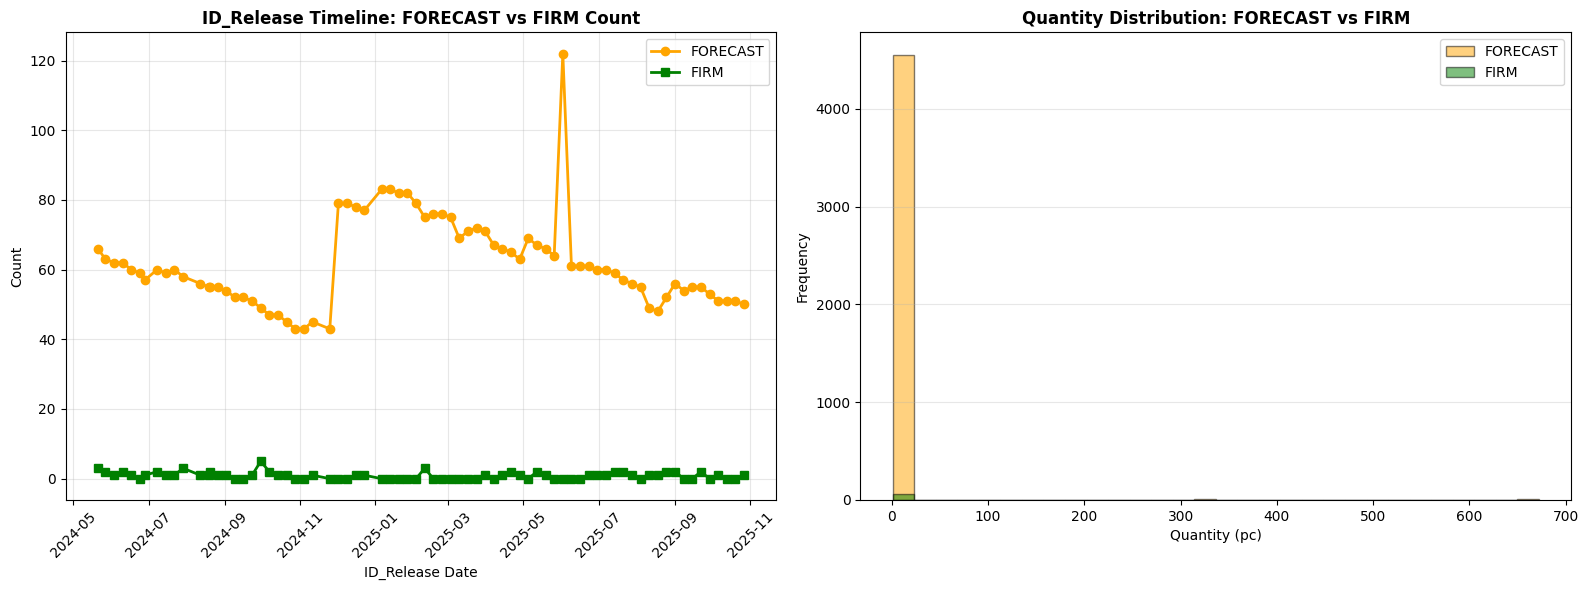

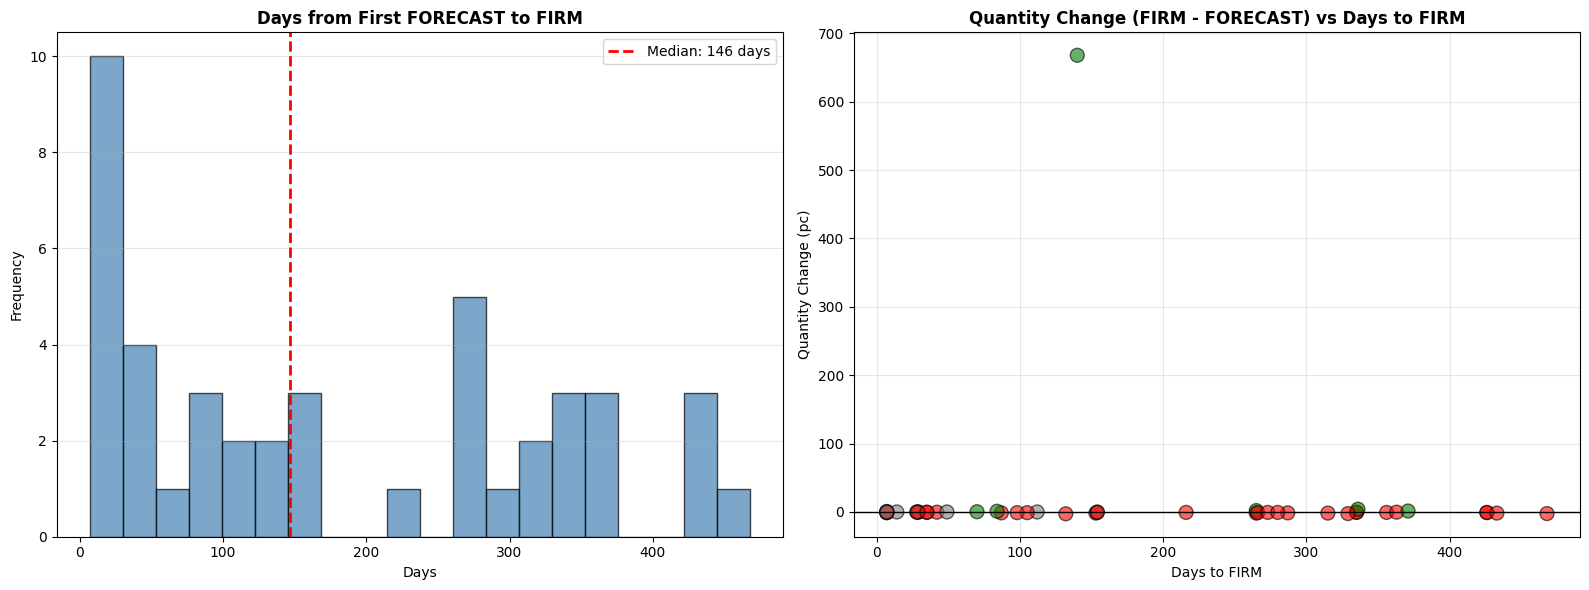

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from datetime import datetime
import pandas as pd

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 읽기
df = pd.read_excel('/content/final_cleaned_data.xlsx')

print("=== 데이터 정보 ===")
print(f"전체 행 수: {len(df)}")
print(f"ID_Release 개수: {df['ID_Release'].nunique()}")
print(f"고유 납품일 개수: {df.groupby(['Year', 'Month', 'Day']).ngroups}")

# ID_Release를 날짜 형식으로 변환하여 정렬
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d')
df = df.sort_values('Release_Date')

# 특정 납품일의 Forecast→Firm 패턴 분석
print("\n=== Forecast→Firm 전환 케이스 찾기 ===")

# 각 납품일별로 그룹화
delivery_groups = df.groupby(['Year', 'Month', 'Day'])

transition_cases = []
for (year, month, day), group in delivery_groups:
    has_forecast = (group['Firm/Forecast'] == 'FORECAST').any()
    has_firm = (group['Firm/Forecast'] == 'FIRM').any()

    if has_forecast and has_firm:
        # Forecast → Firm 전환이 일어난 케이스
        forecast_data = group[group['Firm/Forecast'] == 'FORECAST']
        firm_data = group[group['Firm/Forecast'] == 'FIRM']

        transition_cases.append({
            'delivery_date': f"{year}-{month}-{day}",
            'year': year,
            'month': month,
            'day': day,
            'forecast_count': len(forecast_data),
            'firm_count': len(firm_data),
            'forecast_qty_min': forecast_data['Quantity'].min(),
            'forecast_qty_max': forecast_data['Quantity'].max(),
            'firm_qty': firm_data['Quantity'].iloc[0] if len(firm_data) > 0 else None,
            'first_forecast_release': forecast_data['Release_Date'].min(),
            'first_firm_release': firm_data['Release_Date'].min()
        })

transition_df = pd.DataFrame(transition_cases)
print(f"\n전환 케이스 발견: {len(transition_df)}개")
print(transition_df.head(10))


# 시각화 2: 전체 데이터의 Forecast vs Firm 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2-1: ID_Release별 Forecast/Firm 개수
release_counts = df.groupby(['Release_Date', 'Firm/Forecast']).size().unstack(fill_value=0)

ax = axes[0]
if 'FORECAST' in release_counts.columns:
    ax.plot(release_counts.index, release_counts['FORECAST'],
           marker='o', color='orange', label='FORECAST', linewidth=2)
if 'FIRM' in release_counts.columns:
    ax.plot(release_counts.index, release_counts['FIRM'],
           marker='s', color='green', label='FIRM', linewidth=2)

ax.set_title('ID_Release Timeline: FORECAST vs FIRM Count', fontsize=12, fontweight='bold')
ax.set_xlabel('ID_Release Date', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# 2-2: Quantity 분포 비교
ax = axes[1]
forecast_qty = df[df['Firm/Forecast'] == 'FORECAST']['Quantity']
firm_qty = df[df['Firm/Forecast'] == 'FIRM']['Quantity']

ax.hist(forecast_qty, bins=30, alpha=0.5, color='orange', label='FORECAST', edgecolor='black')
ax.hist(firm_qty, bins=30, alpha=0.5, color='green', label='FIRM', edgecolor='black')

ax.set_title('Quantity Distribution: FORECAST vs FIRM', fontsize=12, fontweight='bold')
ax.set_xlabel('Quantity (pc)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()


# 시각화 3: 전환 시간 분석 (Forecast 첫 발생 → Firm 확정까지 소요 시간)
if len(transition_df) > 0:
    transition_df['days_to_firm'] = (transition_df['first_firm_release'] -
                                      transition_df['first_forecast_release']).dt.days

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 3-1: 전환 소요 시간 분포
    ax = axes[0]
    ax.hist(transition_df['days_to_firm'], bins=20, color='steelblue',
           edgecolor='black', alpha=0.7)
    ax.axvline(transition_df['days_to_firm'].median(), color='red',
              linestyle='--', linewidth=2, label=f"Median: {transition_df['days_to_firm'].median():.0f} days")
    ax.set_title('Days from First FORECAST to FIRM', fontsize=12, fontweight='bold')
    ax.set_xlabel('Days', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 3-2: Quantity 변화 분석
    ax = axes[1]
    transition_df['qty_change'] = transition_df['firm_qty'] - transition_df['forecast_qty_max']

    colors = ['red' if x < 0 else 'green' if x > 0 else 'gray'
              for x in transition_df['qty_change']]

    ax.scatter(transition_df['days_to_firm'], transition_df['qty_change'],
              c=colors, s=100, alpha=0.6, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_title('Quantity Change (FIRM - FORECAST) vs Days to FIRM',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Days to FIRM', fontsize=10)
    ax.set_ylabel('Quantity Change (pc)', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

# 통계 요약
print("\n=== 전환 패턴 통계 ===")
print(f"평균 전환 소요 시간: {transition_df['days_to_firm'].mean():.1f}일")
print(f"중앙값 전환 소요 시간: {transition_df['days_to_firm'].median():.1f}일")
print(f"최소/최대 전환 소요 시간: {transition_df['days_to_firm'].min():.0f}일 / {transition_df['days_to_firm'].max():.0f}일")
print(f"\n평균 수량 변화: {transition_df['qty_change'].mean():.3f}pc")
print(f"수량 증가 케이스: {(transition_df['qty_change'] > 0).sum()}개")
print(f"수량 감소 케이스: {(transition_df['qty_change'] < 0).sum()}개")
print(f"수량 동일 케이스: {(transition_df['qty_change'] == 0).sum()}개")

print("\n 모든 시각화 완료!")